In [2]:
import pandas as pd
import import_ipynb
import nbimporter
from utils import prepareTrainingSet3Sec,prepareTrainingSet30Sec,standardization,metrics,Grafico_Before_After,Grafico_Tre_Valori, ConfrontoGrafico_30_e_3, evaluate_Model, prepareTrainingSet30Sec_Arg , prepareTrainingSet3Sec_Arg  #type: ignore
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV  
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import accuracy_score







I file CSV per il training e il test set sono stati creati con successo.


In [2]:
X_train, X_test, y_train, y_test= prepareTrainingSet30Sec()
# utilizzo la funzione di standardizzazzione presente in utils che usa Standard Scaler

# Creare il modello Logistic
model = LogisticRegression(max_iter=1000, solver='newton-cg')
model.fit(X_train, y_train)

# Prevedere le etichette per il set di test
y_pred = model.predict(X_test)

y_pred_train=model.predict(X_train)
evaluate_Model(y_test,y_pred,y_train,y_pred_train)


---------STATISTICHE TEST----------
Accuratezza: 0.6200
Precision: 0.6292
Recall: 0.6349
F1-score: 0.6264
F2-score: 0.6301
---------STATISTICHE TRAING----------
Accuratezza: 0.8087
Precision: 0.8072
Recall: 0.8074
F1-score: 0.8071
F2-score: 0.8072

=== Analisi ===
Il modello potrebbe soffrire di OVERFITTING (performance molto migliore sul training set).


C:\Users\david\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\utils\optimize.py:319: ConvergenceWarning: newton-cg failed to converge at loss = 0.6157951956699773. Increase the number of iterations.
  warnings.warn(


Con Standardizzazione

In [20]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler


X_train, X_test, y_train, y_test= prepareTrainingSet30Sec()
# utilizzo la funzione di standardizzazzione presente in utils che usa Standard Scaler
X_train,X_test=standardization(X_train,X_test)
# Creare il modello Logistic
model = LogisticRegression(max_iter=10, solver='newton-cg')
model.fit(X_train, y_train)


y_pred = model.predict(X_test)

y_pred_train=model.predict(X_train)
evaluate_Model(y_test,y_pred,y_train,y_pred_train)




---------STATISTICHE TEST----------
Accuratezza: 0.7050
Precision: 0.7222
Recall: 0.7224
F1-score: 0.7177
F2-score: 0.7195
---------STATISTICHE TRAING----------
Accuratezza: 0.9187
Precision: 0.9188
Recall: 0.9174
F1-score: 0.9176
F2-score: 0.9174

=== Analisi ===
Il modello potrebbe soffrire di OVERFITTING (performance molto migliore sul training set).


C:\Users\david\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\utils\optimize.py:319: ConvergenceWarning: newton-cg failed to converge at loss = 0.4500991078278703. Increase the number of iterations.
  warnings.warn(


grid search

In [9]:


 #Definizione del pipeline con standardizzazione e Logistic Regression
pipeline = Pipeline([
    ('scaler', StandardScaler()),  # Standardizzazione delle features
    ('classifier', LogisticRegression(max_iter=100))  # Classificatore Logistic Regression
])

# Definizione degli iperparametri da testare con GridSearch, con combinazioni compatibili
param_grid = [
    {'classifier__C': [0.01, 0.1, 1], 'classifier__penalty': ['l2'], 'classifier__solver': ['lbfgs']},
    {'classifier__C': [0.01, 0.1, 1], 'classifier__penalty': ['l1', 'l2'], 'classifier__solver': ['liblinear']},
    {'classifier__C': [0.01, 0.1, 1], 'classifier__penalty': ['l1', 'l2', 'elasticnet']}  
]

# Inizializzazione della GridSearchCV con validazione incrociata a 5 fold
grid_search = GridSearchCV(pipeline, param_grid, cv=5, scoring='accuracy', n_jobs=-1, verbose=2)

# Esecuzione della ricerca
grid_search.fit(X_train, y_train)

# Migliori parametri trovati
print("Migliori iperparametri trovati:", grid_search.best_params_)





Fitting 5 folds for each of 18 candidates, totalling 90 fits


KeyboardInterrupt: 

Ora utilizzo dataset con argumentation ed applico i paramentri forniti dalla grid search

In [3]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler


X_train, X_test, y_train, y_test= prepareTrainingSet30Sec_Arg()
# utilizzo la funzione di standardizzazzione presente in utils che usa Standard Scaler
X_train,X_test=standardization(X_train,X_test)
# Creare il modello Logistic
model = LogisticRegression(max_iter=100, C=  1, l1_ratio=0.5, penalty= 'elasticnet', solver= 'saga')
model.fit(X_train, y_train)


y_pred = model.predict(X_test)

y_pred_train=model.predict(X_train)
evaluate_Model(y_test,y_pred,y_train,y_pred_train)

---------STATISTICHE TEST----------
Accuratezza: 0.8608
Precision: 0.8583
Recall: 0.8572
F1-score: 0.8574
F2-score: 0.8572
---------STATISTICHE TRAING----------
Accuratezza: 0.8812
Precision: 0.8825
Recall: 0.8822
F1-score: 0.8820
F2-score: 0.8820

=== Analisi ===
Il modello sembra bilanciato e generalizza bene.


C:\Users\david\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


In [5]:
from utils import prepareTrainArgumentation,prepareTest
X_train,y_train = prepareTrainArgumentation()
X_test,y_test=prepareTest()

model = LogisticRegression(max_iter=1000, C=  1, l1_ratio=0.5, penalty= 'elasticnet', solver= 'saga')
model.fit(X_train, y_train)


y_pred = model.predict(X_test)

y_pred_train=model.predict(X_train)
evaluate_Model(y_test,y_pred,y_train,y_pred_train)


---------STATISTICHE TEST----------
Accuratezza: 0.2733
Precision: 0.2699
Recall: 0.3011
F1-score: 0.2663
F2-score: 0.2812
---------STATISTICHE TRAING----------
Accuratezza: 0.3514
Precision: 0.3194
Recall: 0.3380
F1-score: 0.3153
F2-score: 0.3254

=== Analisi ===
Il modello potrebbe soffrire di OVERFITTING (performance molto migliore sul training set).


C:\Users\david\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


Accuracy: 0.2866666666666667
Classification Report:
              precision    recall  f1-score   support

       blues       0.14      0.26      0.18        35
   classical       0.33      0.50      0.40        20
     country       0.24      0.22      0.23        37
       disco       0.38      0.32      0.35        34
      hiphop       0.25      0.12      0.17        24
        jazz       0.00      0.00      0.00        33
       metal       0.31      0.63      0.42        30
         pop       0.54      0.65      0.59        23
      reggae       0.27      0.28      0.27        29
        rock       0.23      0.09      0.12        35

    accuracy                           0.29       300
   macro avg       0.27      0.31      0.27       300
weighted avg       0.26      0.29      0.26       300

Confusion Matrix:
[[ 9  7  5  4  0  0  7  0  3  0]
 [10 10  0  0  0  0  0  0  0  0]
 [13  3  8  0  2  0  6  2  2  1]
 [ 3  1  3 11  3  0  4  4  2  3]
 [ 2  0  2  4  3  0  1  3  9  0]
 [ 7  

C:\Users\david\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
C:\Users\david\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capita

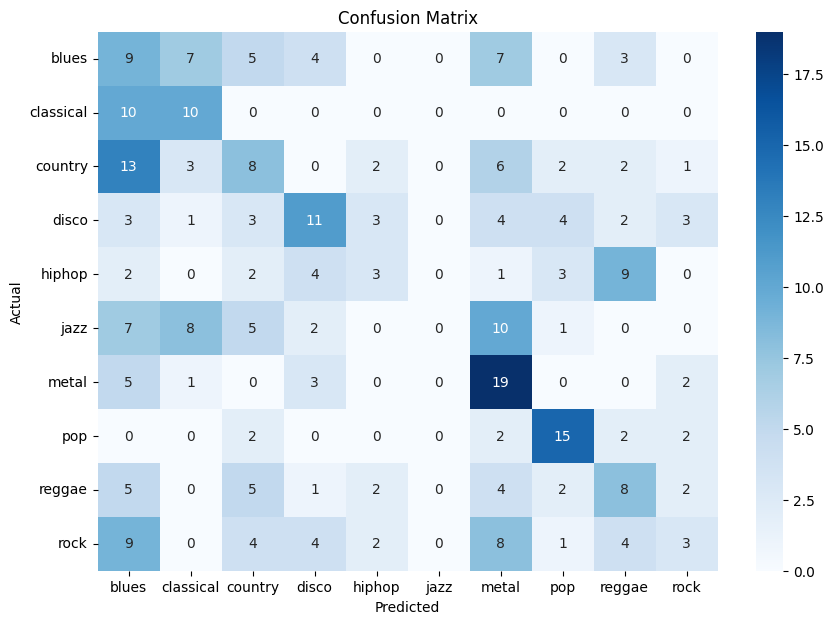

In [8]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Carica i dati di training aumentati
train_df = pd.read_csv('Data/augmented_train_data_30.csv')

# Carica i dati di test
test_df = pd.read_csv('Data/test_data_30.csv')  # Assicurati di avere un file di test separato

# Prepara i dati di training
X_train = train_df.iloc[:, 1:-1]
y_train = train_df['label']

# Prepara i dati di test
X_test = test_df.iloc[:, 1:-1]
y_test = test_df['label']

# Allena il modello di regressione logistica
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# Effettua le predizioni sul set di test
y_pred = model.predict(X_test)

# Valuta il modello
accuracy = accuracy_score(y_test, y_pred)
classification_rep = classification_report(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)

print(f"Accuracy: {accuracy}")
print("Classification Report:")
print(classification_rep)
print("Confusion Matrix:")
print(conf_matrix)

# Visualizza la matrice di confusione
plt.figure(figsize=(10, 7))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=model.classes_, yticklabels=model.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

FACCIO IL LASSO

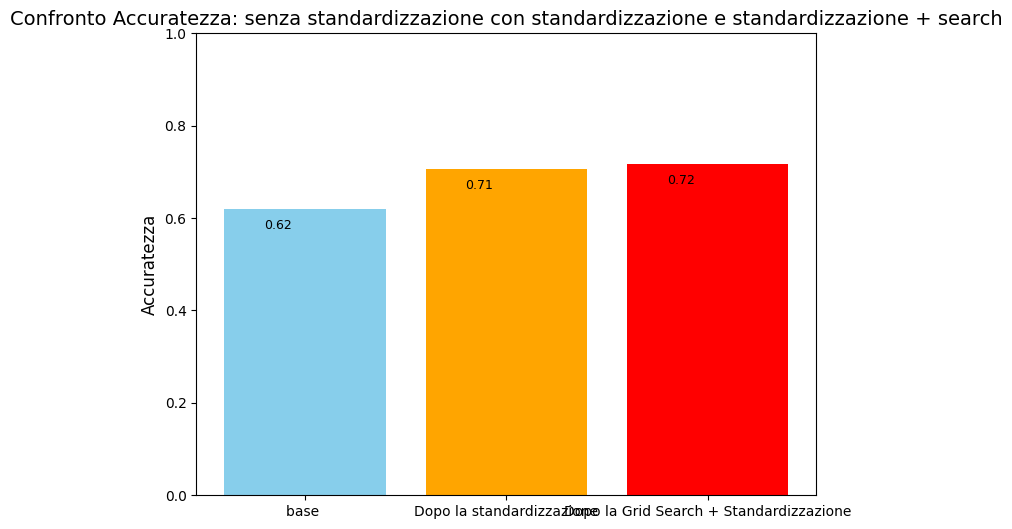

In [8]:
Grafico_Tre_Valori(before_30sec,before_30sec_standadization,after_30sec)

con 3 secondi

In [4]:

X_train, X_test, y_train, y_test= prepareTrainingSet3Sec()
# Creare il modello Logistic
model = LogisticRegression(max_iter=100, solver='newton-cg')
model.fit(X_train, y_train)

# Prevedere le etichette per il set di test
y_pred = model.predict(X_test)

y_pred_train=model.predict(X_train)
evaluate_Model(y_test,y_pred,y_train,y_pred_train)


---------STATISTICHE TEST----------
Accuratezza: 0.5495
Precision: 0.5440
Recall: 0.5513
F1-score: 0.5377
F2-score: 0.5433
---------STATISTICHE TRAING----------
Accuratezza: 0.5577
Precision: 0.5468
Recall: 0.5569
F1-score: 0.5463
F2-score: 0.5513

=== Analisi ===
Il modello potrebbe soffrire di UNDERFITTING (performance bassa su entrambi i set).


C:\Users\david\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\utils\optimize.py:319: ConvergenceWarning: newton-cg failed to converge at loss = 1.2765689137785912. Increase the number of iterations.
  warnings.warn(


In [13]:
 #Definizione del pipeline con standardizzazione e Logistic Regression
pipeline = Pipeline([
    ('scaler', StandardScaler()),  # Standardizzazione delle features
    ('classifier', LogisticRegression(max_iter=1000))  # Classificatore Logistic Regression
])

# Definizione degli iperparametri da testare con GridSearch, con combinazioni compatibili
param_grid = [
    {'classifier__C': [0.01, 0.1, 1], 'classifier__penalty': ['l2'], 'classifier__solver': ['lbfgs']},
    {'classifier__C': [0.01, 0.1, 1], 'classifier__penalty': ['l1', 'l2'], 'classifier__solver': ['liblinear']},
    {'classifier__C': [0.01, 0.1, 1], 'classifier__penalty': ['l1', 'l2', 'elasticnet'], 
     'classifier__solver': ['saga'], 'classifier__l1_ratio': [0.5]}  # l1_ratio solo per elasticnet con saga
]

# Inizializzazione della GridSearchCV con validazione incrociata a 5 fold
grid_search = GridSearchCV(pipeline, param_grid, cv=5, scoring='accuracy', n_jobs=-1, verbose=2)

# Esecuzione della ricerca
grid_search.fit(X_train, y_train)

# Migliori parametri trovati
print("Migliori iperparametri trovati:", grid_search.best_params_)


Fitting 5 folds for each of 18 candidates, totalling 90 fits
Migliori iperparametri trovati: {'classifier__C': 1, 'classifier__l1_ratio': 0.5, 'classifier__penalty': 'elasticnet', 'classifier__solver': 'saga'}


In [5]:
# utilizzo la funzione di standardizzazzione presente in utils che usa Standard Scaler
model = LogisticRegression(max_iter=100, C=  1, l1_ratio=0.5, penalty= 'elasticnet', solver= 'saga')
X_train, X_test= standardization(X_train, X_test)
model.fit(X_train, y_train)
            # Valutazione del modello
y_pred = model.predict(X_test)
y_pred_train=model.predict(X_train)
evaluate_Model(y_test,y_pred,y_train,y_pred_train)

#after_3sec=accuracy_score(y_test, y_pred)
#logisticRegression3Sec= after_3sec

---------STATISTICHE TEST----------
Accuratezza: 0.7337
Precision: 0.7307
Recall: 0.7347
F1-score: 0.7312
F2-score: 0.7330
---------STATISTICHE TRAING----------
Accuratezza: 0.7344
Precision: 0.7317
Recall: 0.7341
F1-score: 0.7326
F2-score: 0.7335

=== Analisi ===
Il modello sembra bilanciato e generalizza bene.


C:\Users\david\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


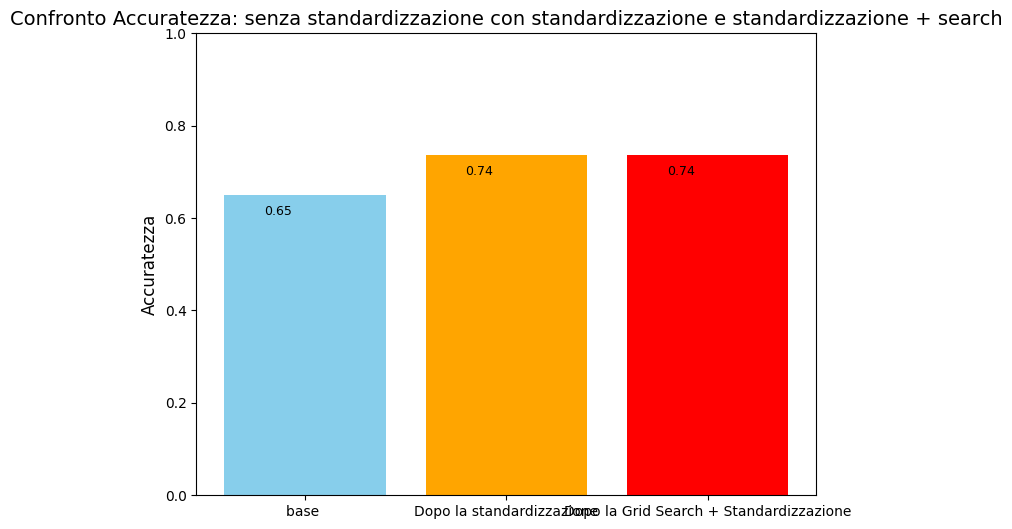

In [14]:
Grafico_Tre_Valori(before_3sec,before_3sec_standadization,after_3sec)


In [11]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler


X_train_arg, X_test_arg, y_train_arg, y_test_arg= prepareTrainingSet30Sec_Arg()
X_train, X_test, y_train, y_test= prepareTrainingSet30Sec()
# utilizzo la funzione di standardizzazzione presente in utils che usa Standard Scaler
X_train_arg,X_test_arg=standardization(X_train_arg,X_test_arg)
X_train,X_test=standardization(X_train,X_test)

# Creare il modello Logistic
model = LogisticRegression(max_iter=100, C=  1, l1_ratio=0.5, penalty= 'elasticnet', solver= 'saga')
model.fit(X_train_arg, y_train_arg)


y_pred = model.predict(X_test)

y_pred_train_arg=model.predict(X_train_arg)
evaluate_Model(y_test,y_pred,y_train_arg,y_pred_train_arg)

---------STATISTICHE TEST----------
Accuratezza: 0.8050
Precision: 0.8134
Recall: 0.8150
F1-score: 0.8095
F2-score: 0.8115
---------STATISTICHE TRAING----------
Accuratezza: 0.8485
Precision: 0.8484
Recall: 0.8495
F1-score: 0.8487
F2-score: 0.8491

=== Analisi ===
Il modello sembra bilanciato e generalizza bene.


C:\Users\david\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


In [12]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Funzione di standardizzazione
def standardization(X_train, X_test):
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    return X_train_scaled, X_test_scaled

# Funzione per valutare il modello
def evaluate_Model(y_test, y_pred, y_train_arg, y_pred_train_arg):
    print("---------STATISTICHE TEST----------")
    print(f"Accuratezza: {accuracy_score(y_test, y_pred):.4f}")
    print(f"Precision: {precision_score(y_test, y_pred, average='macro'):.4f}")
    print(f"Recall: {recall_score(y_test, y_pred, average='macro'):.4f}")
    print(f"F1-score: {f1_score(y_test, y_pred, average='macro'):.4f}")
    
    print("---------STATISTICHE TRAINING----------")
    print(f"Accuratezza: {accuracy_score(y_train_arg, y_pred_train_arg):.4f}")
    print(f"Precision: {precision_score(y_train_arg, y_pred_train_arg, average='macro'):.4f}")
    print(f"Recall: {recall_score(y_train_arg, y_pred_train_arg, average='macro'):.4f}")
    print(f"F1-score: {f1_score(y_train_arg, y_pred_train_arg, average='macro'):.4f}")

# Supponiamo che prepareTrainingSet30Sec_Arg e prepareTrainingSet30Sec siano definite correttamente
X_train_arg, X_test_arg, y_train_arg, y_test_arg = prepareTrainingSet30Sec_Arg()
X_train, X_test, y_train, y_test = prepareTrainingSet30Sec()

# Standardizzazione dei dati
X_train_arg, X_test_arg = standardization(X_train_arg, X_test_arg)
X_train, X_test = standardization(X_train, X_test)

# Creare il modello Random Forest
model = RandomForestClassifier(n_estimators=200, max_depth=15, random_state=42)
model.fit(X_train_arg, y_train_arg)

# Previsioni sui dati di test
y_pred = model.predict(X_test)

# Previsioni sui dati di training aumentati
y_pred_train_arg = model.predict(X_train_arg)

# Valutazione del modello
evaluate_Model(y_test, y_pred, y_train_arg, y_pred_train_arg)

---------STATISTICHE TEST----------
Accuratezza: 1.0000
Precision: 1.0000
Recall: 1.0000
F1-score: 1.0000
---------STATISTICHE TRAINING----------
Accuratezza: 0.9998
Precision: 0.9998
Recall: 0.9998
F1-score: 0.9998


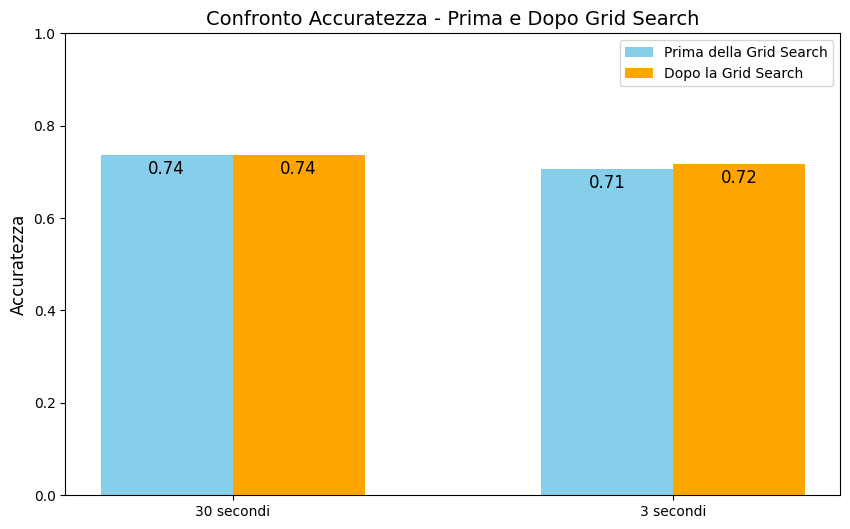

In [16]:
ConfrontoGrafico_30_e_3(before_3sec_standadization,before_30sec_standadization,after_3sec,after_30sec)